Eigenvalues: [3. 2.]
Eigenvectors (columns): [[ 1.         -0.70710678]
 [ 0.          0.70710678]]
[1. 0.]
λ=3.0: A@v=[3. 0.], λv=[3. 0.], match=True
[-0.70710678  0.70710678]
λ=2.0: A@v=[-1.4142  1.4142], λv=[-1.4142  1.4142], match=True
Symmetric matrix eigenvalues: [1.43844719 5.56155281]
Eigenvectors orthogonal? True
det(S) = product of eigenvalues: 8.0 == 8.0
trace(S) = sum of eigenvalues: 7.0 == 7.0
Covariance matrix shape: (4, 4)
Explained variance ratio: [0.9246 0.0531 0.0171 0.0052]
Cumulative (top 2): 0.9777
Reduced shape: (150, 2)
sklearn explained variance ratio: [0.9246 0.0531]
Results match (up to sign): True


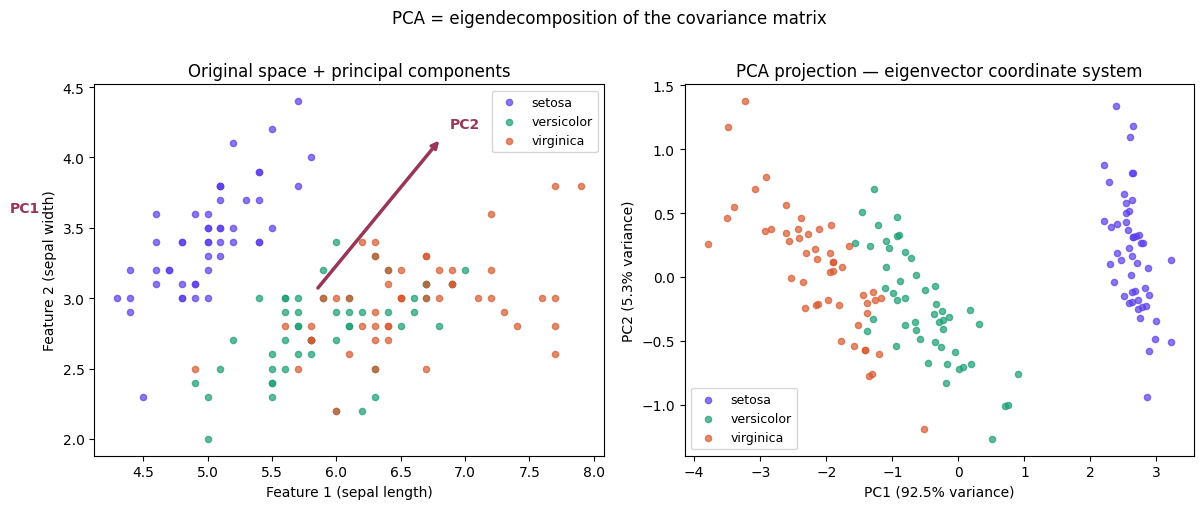

Save as day06_eigenvalues.ipynb and push to GitHub.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris

# ── 1. Manual eigendecomposition ─────────────────────────
A = np.array([[3., 1.],
              [0., 2.]])

eigenvalues, eigenvectors = np.linalg.eig(A)
print("Eigenvalues:", eigenvalues)          # [3. 2.]
print("Eigenvectors (columns):", eigenvectors)

# Verify: A @ v = λv for each pair
for i in range(len(eigenvalues)):
    v   = eigenvectors[:, i]
    print(v)
    lam = eigenvalues[i]
    lhs = A @ v
    rhs = lam * v
    print(f"λ={lam}: A@v={lhs.round(4)}, λv={rhs.round(4)}, match={np.allclose(lhs,rhs)}")

# ── 2. Eigenvalues of a symmetric matrix ─────────────────
# Symmetric matrices: real eigenvalues, orthogonal eigenvectors — guaranteed
S = np.array([[4., 2.],
              [2., 3.]])
evals, evecs = np.linalg.eigh(S)   # eigh for symmetric — more stable than eig
print("Symmetric matrix eigenvalues:", evals)
print("Eigenvectors orthogonal?", np.allclose(evecs[:,0] @ evecs[:,1], 0))  # True ✓
print("det(S) = product of eigenvalues:", np.prod(evals).round(4),"==", np.linalg.det(S).round(4))   # same ✓
print("trace(S) = sum of eigenvalues:",  np.sum(evals).round(4),"==", np.trace(S).round(4))        # same ✓

# ── 3. PCA from scratch ──────────────────────────────────
iris = load_iris()
X = iris.data   # (150, 4) — 4 features

# Step 1: centre the data
X_c = X - X.mean(axis=0)

# Step 2: covariance matrix
C = (X_c.T @ X_c) / (len(X_c) - 1)
print("Covariance matrix shape:", C.shape)   # (4,4)

# Step 3: eigendecomposition of covariance matrix
evals, evecs = np.linalg.eigh(C)   # eigh for symmetric

# Step 4: sort by eigenvalue descending
idx   = np.argsort(evals)[::-1]
evals = evals[idx]
evecs = evecs[:, idx]

# Step 5: explained variance ratio
evr = evals / evals.sum()
print("Explained variance ratio:", evr.round(4))
print("Cumulative (top 2):", evr[:2].sum().round(4))

# Step 6: project onto top-2 principal components
X_pca = X_c @ evecs[:, :2]
print("Reduced shape:", X_pca.shape)   # (150, 2)

# ── 4. Compare to sklearn ────────────────────────────────
sk_pca = PCA(n_components=2)
X_sk   = sk_pca.fit_transform(X_c)
print("sklearn explained variance ratio:", sk_pca.explained_variance_ratio_.round(4))
# Should match yours (up to sign flip — eigenvectors can point either way)
print("Results match (up to sign):",np.allclose(np.abs(X_pca), np.abs(X_sk), atol=1e-4))

# ── 5. Visualise PCA + principal components ──────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: original 2D slice with eigenvectors overlaid
ax = axes[0]
colors = ['#5B3FE8','#1D9E75','#D85A30']
for i, name in enumerate(iris.target_names):
    mask = iris.target == i
    ax.scatter(X[mask,0], X[mask,1], c=colors[i], label=name, s=20, alpha=0.7)

# Draw first 2 eigenvectors scaled by sqrt(eigenvalue)
origin = X.mean(axis=0)[:2]
for i in range(2):
    vec = evecs[:2, i] * np.sqrt(evals[i])
    ax.annotate('', xy=origin+vec*3, xytext=origin,
                arrowprops=dict(arrowstyle='->', color='#993556', lw=2.5))
    ax.text(*(origin+vec*3.2), f'PC{i+1}', color='#993556', fontsize=10, fontweight='bold')

ax.set_xlabel('Feature 1 (sepal length)'); ax.set_ylabel('Feature 2 (sepal width)')
ax.set_title('Original space + principal components'); ax.legend(fontsize=9)

# Right: projected PCA space
ax2 = axes[1]
for i, name in enumerate(iris.target_names):
    mask = iris.target == i
    ax2.scatter(X_pca[mask,0], X_pca[mask,1], c=colors[i], label=name, s=20, alpha=0.7)
ax2.set_xlabel(f'PC1 ({evr[0]*100:.1f}% variance)')
ax2.set_ylabel(f'PC2 ({evr[1]*100:.1f}% variance)')
ax2.set_title('PCA projection — eigenvector coordinate system')
ax2.legend(fontsize=9)

plt.suptitle('PCA = eigendecomposition of the covariance matrix', y=1.01)
plt.tight_layout()
plt.show()
print("Save as day06_eigenvalues.ipynb and push to GitHub.")